In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [9]:
df = pd.read_csv("../data/german_credit.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (1000, 11)

First 5 rows:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [10]:
print(df.columns.tolist())
print(df.head(2))

['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   

   Credit amount  Duration   Purpose  Risk  
0           1169         6  radio/TV  good  
1           5951        48  radio/TV   bad  


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB
None

=== Missing Values ===
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose

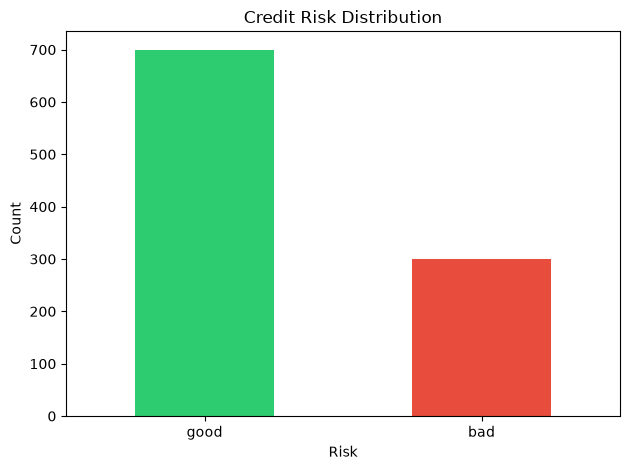

In [11]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
print(df["Risk"].value_counts())

# Visualise target balance
df["Risk"].value_counts().plot(kind="bar", color=[("#2ecc71"), ("#e74c3c")])
plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
df_clean = df.copy()

# Encode target: good = 0, bad = 1
df_clean["Risk"] = df_clean["Risk"].map({"good": 0, "bad": 1})

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include="object").columns

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("✅ Encoding done")
print("Categorical columns encoded:", list(cat_cols))

# Split features and target
X = df_clean.drop("Risk", axis=1)
y = df_clean["Risk"]

# Scale numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print("\n✅ SMOTE applied")
print("Resampled class distribution:", pd.Series(y_resampled).value_counts().to_dict())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
print(f"\n✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

✅ Encoding done
Categorical columns encoded: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

✅ SMOTE applied
Resampled class distribution: {0: 700, 1: 700}

✅ Train size: 1120 | Test size: 280


In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("✅ XGBoost model trained!")

✅ XGBoost model trained!


In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("✅ Logistic Regression model trained!")

✅ Logistic Regression model trained!



  XGBoost
AUC-ROC Score : 0.8853

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.75      0.81      0.78       140
  Bad Credit       0.79      0.73      0.76       140

    accuracy                           0.77       280
   macro avg       0.77      0.77      0.77       280
weighted avg       0.77      0.77      0.77       280



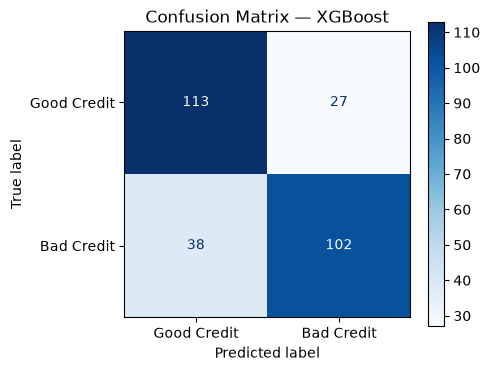


  Logistic Regression
AUC-ROC Score : 0.8079

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.76      0.74      0.75       140
  Bad Credit       0.74      0.76      0.75       140

    accuracy                           0.75       280
   macro avg       0.75      0.75      0.75       280
weighted avg       0.75      0.75      0.75       280



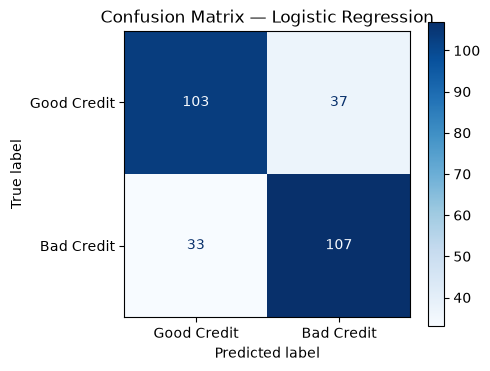

In [15]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"AUC-ROC Score : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Good Credit","Bad Credit"]))
    
    # Confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Good Credit", "Bad Credit"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()
    
    return auc, y_prob

auc_xgb, prob_xgb = evaluate_model(xgb_model, "XGBoost", X_test, y_test)
auc_lr,  prob_lr  = evaluate_model(lr_model,  "Logistic Regression", X_test, y_test)

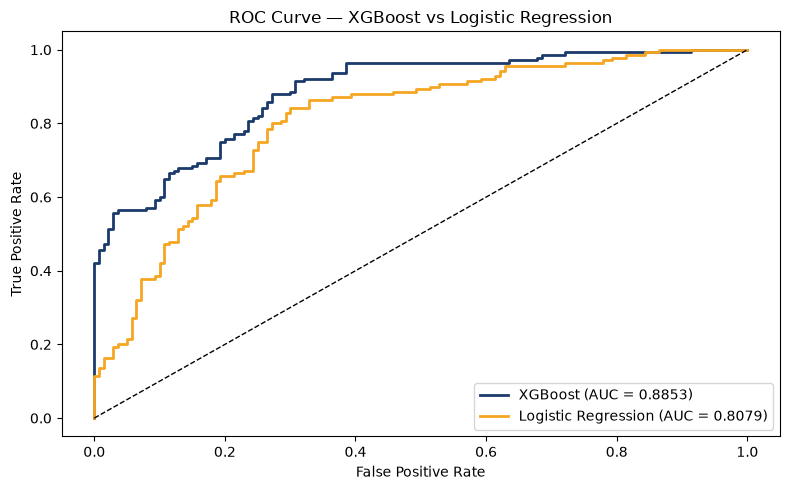

In [16]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, prob_lr)

plt.figure(figsize=(8, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.4f})", color="#1B3A6B", linewidth=2)
plt.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC = {auc_lr:.4f})", color="#F5A623", linewidth=2)
plt.plot([0,1],[0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost vs Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

✅ SHAP values computed!


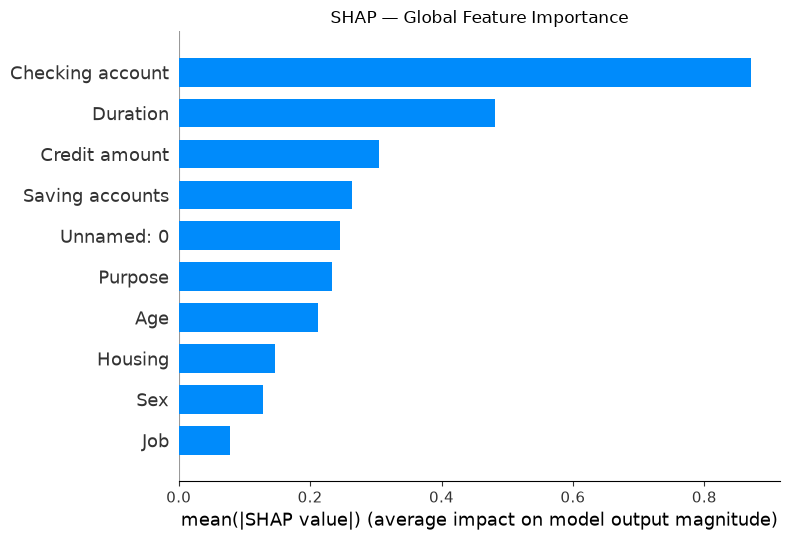

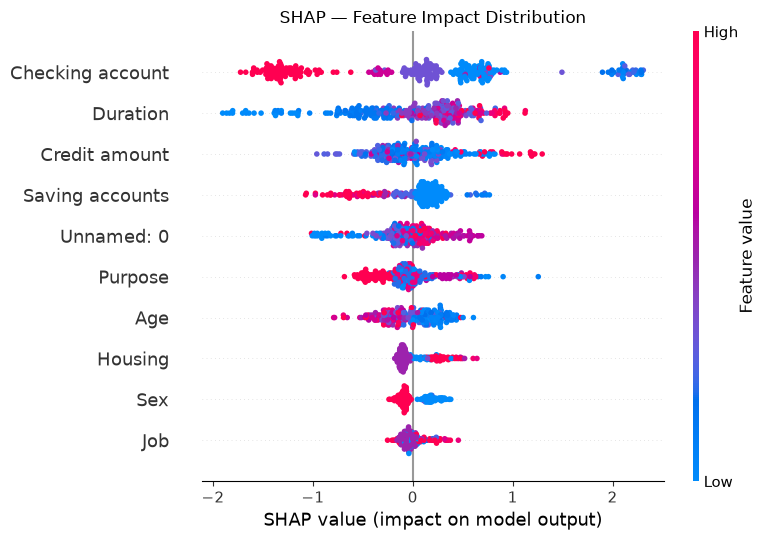

In [17]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values computed!")

# Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP — Global Feature Importance")
plt.tight_layout()
plt.show()

# SHAP beeswarm plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP — Feature Impact Distribution")
plt.tight_layout()
plt.show()

Applicant 0 — Prediction: Bad Credit ❌
Approval Probability: 47.9%


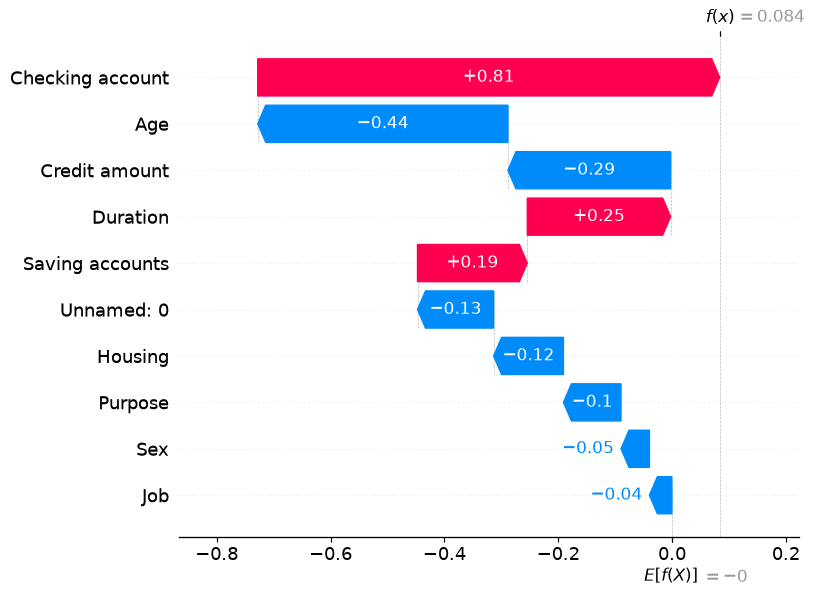

In [18]:
# Pick applicant index 0 as example
applicant_idx = 0
applicant_data = X_test.iloc[[applicant_idx]]
applicant_shap = shap_values[applicant_idx]

print(f"Applicant {applicant_idx} — Prediction: {'Bad Credit ❌' if xgb_model.predict(applicant_data)[0] == 1 else 'Good Credit ✅'}")
print(f"Approval Probability: {xgb_model.predict_proba(applicant_data)[0][0]*100:.1f}%")

# Waterfall plot
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    applicant_shap,
    feature_names=X_test.columns.tolist(),
    show=True
)

In [19]:
import joblib

joblib.dump(xgb_model, "../models/xgb_model.pkl")
joblib.dump(lr_model,  "../models/lr_model.pkl")
joblib.dump(scaler,    "../models/scaler.pkl")

print("✅ Models saved to /models folder!")

✅ Models saved to /models folder!


In [20]:
print(f"Original dataset     : {df.shape[0]} applicants")
print(f"After SMOTE          : {X_resampled.shape[0]} applicants")
print(f"Training set         : {X_train.shape[0]} applicants")
print(f"Test set             : {X_test.shape[0]} applicants")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts().rename({0:'Good Credit', 1:'Bad Credit'}))

Original dataset     : 1000 applicants
After SMOTE          : 1400 applicants
Training set         : 1120 applicants
Test set             : 280 applicants

Class distribution after SMOTE:
Risk
Good Credit    700
Bad Credit     700
Name: count, dtype: int64
